# Lab 3 - Machine Learning - VICTORION Antonin
## Decision Tree and Random Forest on Wisconsin Breast Dataset

### PART 1: Data Exploration

Importing the Required Libraries

We first import the main Python libraries required for data manipulation and visualization.

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

Loading the Dataset

The Wisconsin Breast Cancer Dataset is a binary classification dataset containing information about cell nuclei.

It contains 569 observations and 30 numerical features. The target variable indicates whether a tumor is malignant or benign.

In [12]:
data = load_breast_cancer(as_frame = True)
df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Basic Information About the Dataset

We now inspect the structure of the dataset, including the number of observations, the number of features, the data types, and the presence of missing values.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

 Descriptive Statistics

Descriptive statistics allow us to understand the distribution of the numerical features.

We will examine the mean, standard deviation, minimum, maximum, and quartiles of each feature.

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Target Variable Distribution

The target variable represents the diagnosis of the tumor.

We will examine the number of observations in each class to determine whether the dataset is balanced.

In [14]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [15]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

Data Transformation and Normalization

The features have different numerical scales. For example, some features have relatively small values, while others have much larger values.

To make the features comparable, we can apply a scaling transformation.

A common approach is Standardization, which transforms each feature so that it has a mean close to 0 and a standard deviation close to 1.

This can be performed using the StandardScaler from scikit-learn.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


The dataset is now ready for the next part of the lab, where we will train and evaluate a Decision Tree classifier.

### PART 2: Decision Trees

#### Train a Decision Tree Model

##### Split the dataset into training and testings sets

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Train the model - Gini

We first train a Decision Tree using the Gini impurity criterion.

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced')

dt_gini.fit(X_train, y_train)

y_train_pred = dt_gini.predict(X_train)
y_test_pred = dt_gini.predict(X_test)


##### Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"Accuracy Train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_test_pred):.4f}\n")

Accuracy Train : 1.0000
Accuracy Test  : 0.9298



In [38]:
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.89      0.93      0.91        42
      benign       0.96      0.93      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



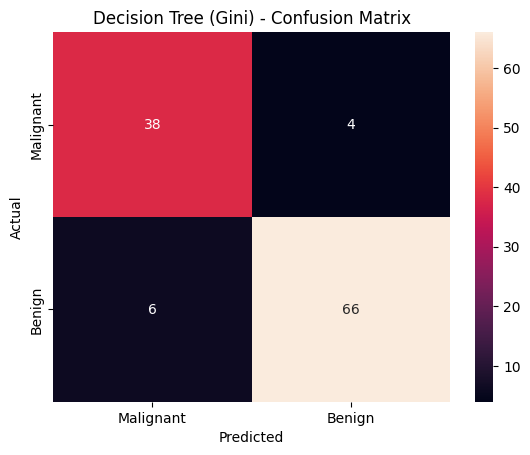

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (Gini) - Confusion Matrix")
plt.show()

### Decision Tree Results

The Decision Tree achieved **100% accuracy on the training set** and **92.98% on the testing set**.

The difference between training and testing performance indicates **overfitting**. However, the testing results remain strong, with an overall F1-score of about **0.93**.

For malignant tumors, the recall is **0.93**, meaning that most malignant cases were correctly identified.


## Train the model - Entropy

In [40]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced')

dt_entropy.fit(X_train, y_train)

y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)

#### Evaluation

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"Accuracy Train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_test_pred):.4f}\n")

Accuracy Train : 1.0000
Accuracy Test  : 0.9123



In [42]:
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



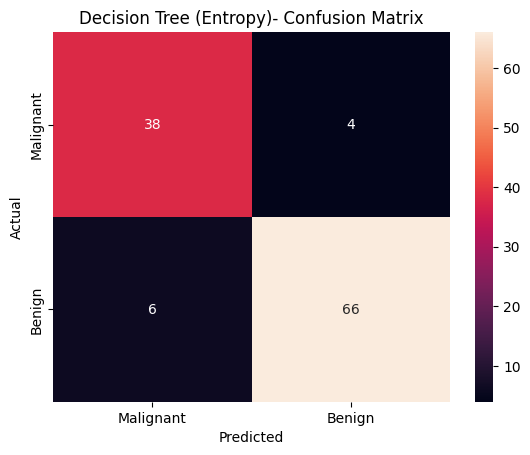

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree (Entropy)- Confusion Matrix")
plt.show()

### Gini vs Entropy

The **Gini criterion performed better** in our experiment.

* Gini accuracy: **92.98%**
* Entropy accuracy: **91.23%**

Therefore, Gini provided slightly better performance on the testing set for this dataset.


Decision Tree Visualization

We visualize the structure of the trained Decision Tree.

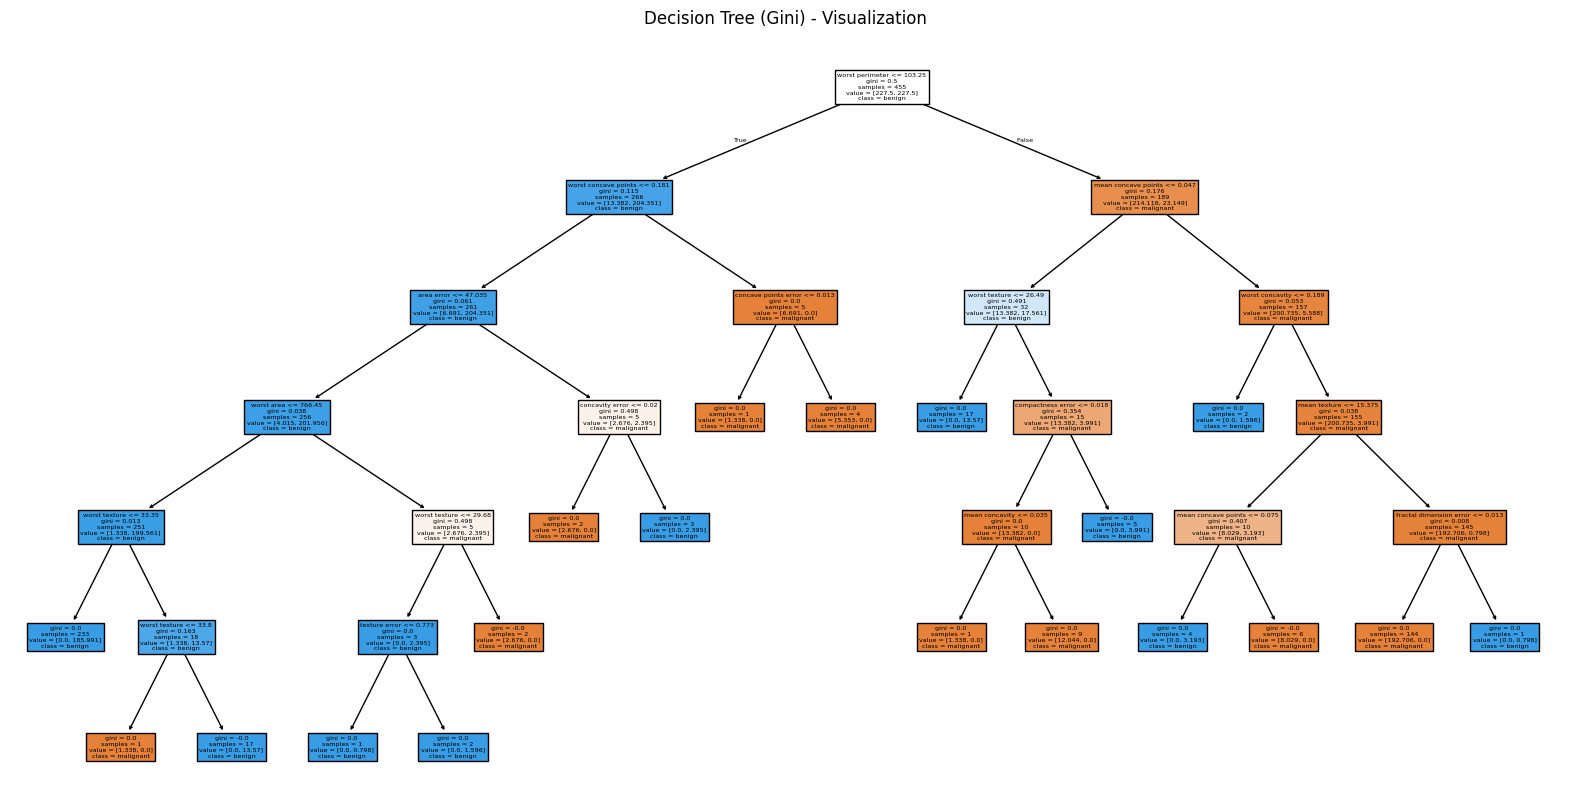

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_gini, filled=True, feature_names=X.columns, class_names=data.target_names)
plt.title("Decision Tree (Gini) - Visualization")

plt.show()

#### Hyperparameter Tuning

##### Feature Importance

We analyze which features are the most important for the Decision Tree.

In [46]:
feature_importance = pd.Series(
    dt_gini.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

worst perimeter         0.705931
mean concave points     0.089177
worst texture           0.062538
worst concave points    0.053458
compactness error       0.027027
worst concavity         0.013389
worst area              0.011809
area error              0.011241
concavity error         0.011111
mean texture            0.007331
dtype: float64

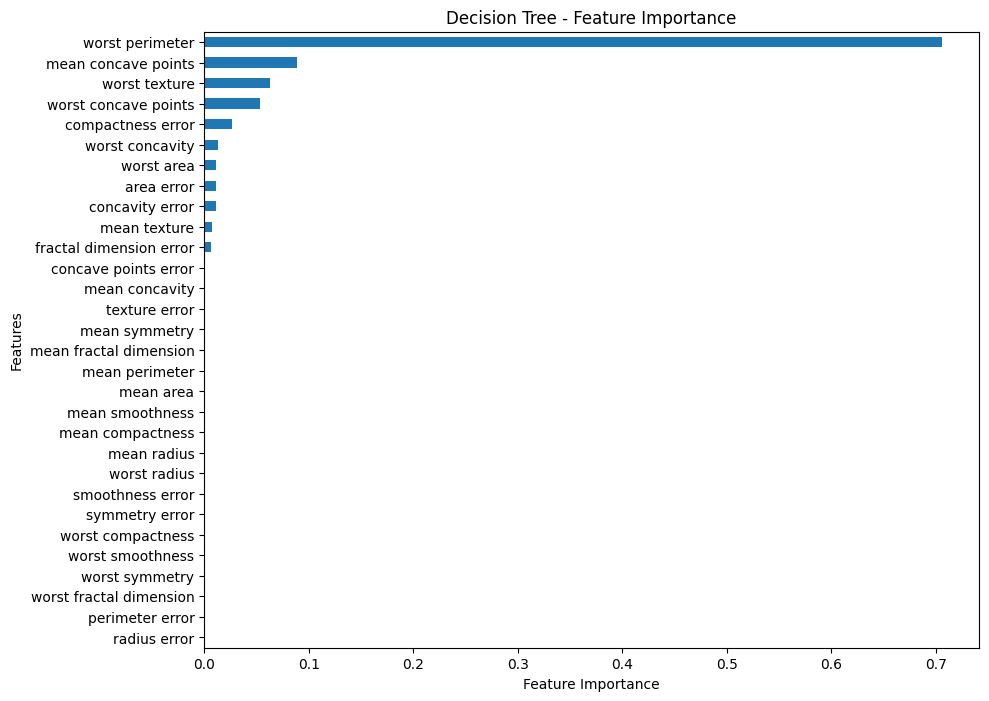

In [47]:
plt.figure(figsize=(10, 8))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Decision Tree - Feature Importance")
plt.show()

##### Decision Tree Feature Importance

The **worst perimeter** is by far the most important feature, with an importance of approximately **0.706**.

Other important features include **mean concave points**, **worst texture**, and **worst concave points**.

These features are related to the size and shape of cell nuclei, which makes their importance consistent with the characteristics measured in this dataset.


##### Effect of Maximum Tree Depth

We investigate how the maximum depth of the tree affects training and testing accuracy.

In [49]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )
    
    test_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

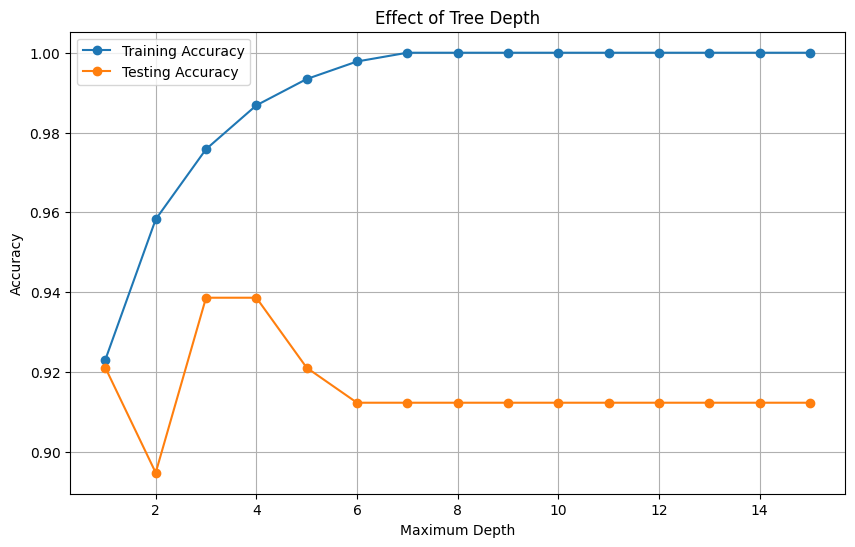

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth")
plt.legend()
plt.grid()
plt.show()

### Tree Depth Analysis

Increasing the tree depth improves the model's ability to fit the training data.

However, a very deep tree can overfit, as shown by the difference between training and testing accuracy.

Limiting the depth makes the model simpler and more interpretable, but an excessively shallow tree can underfit the data.


##### Minimum Samples per Leaf

We also investigate the effect of the minimum number of samples required in a leaf.

In [51]:
min_samples = [1, 2, 5, 10, 20, 30]

train_leaf_scores = []
test_leaf_scores = []

for min_leaf in min_samples:
    model = DecisionTreeClassifier(
        criterion="gini",
        min_samples_leaf=min_leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_leaf_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )
    
    test_leaf_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

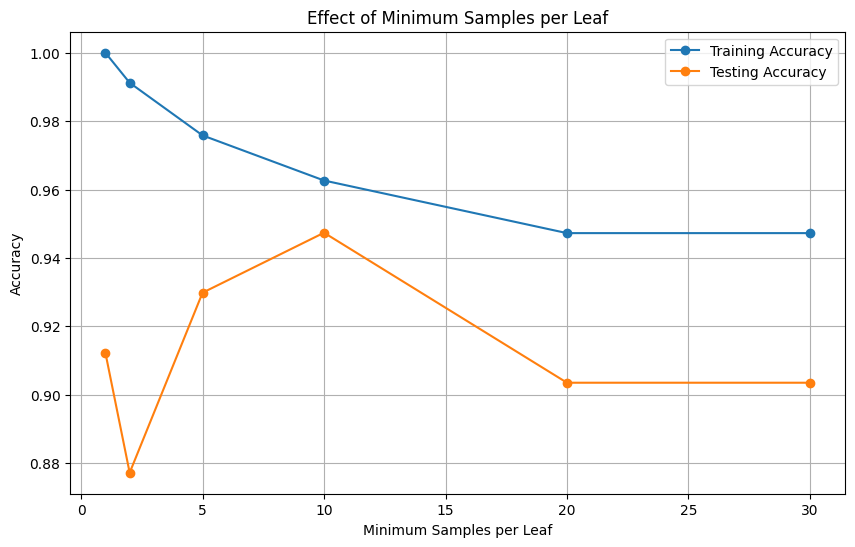

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(min_samples, train_leaf_scores, marker="o", label="Training Accuracy")
plt.plot(min_samples, test_leaf_scores, marker="o", label="Testing Accuracy")

plt.xlabel("Minimum Samples per Leaf")
plt.ylabel("Accuracy")
plt.title("Effect of Minimum Samples per Leaf")
plt.legend()
plt.grid()
plt.show()

### Minimum Samples per Leaf

Increasing the minimum number of samples per leaf reduces the complexity of the Decision Tree.

This can reduce overfitting, but using a value that is too large may decrease the model's ability to learn complex patterns.


### PART 3: Random Forest

##### Training the Random Forest

We train a Random Forest using the same training and testing sets as the Decision Tree.

In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

##### Evaluation

We evaluate the Random Forest using the same metrics as the Decision Tree.

In [54]:
y_rf_train_pred = random_forest_model.predict(X_train)
y_rf_test_pred = random_forest_model.predict(X_test)

print(classification_report(y_test, y_rf_test_pred, target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Random Forest Results

The Random Forest achieved an accuracy of **96%** on the testing set.

The F1-score is **0.94 for malignant tumors** and **0.97 for benign tumors**.

Compared with the Decision Tree, the Random Forest provides better testing performance and a smaller gap between training and testing performance.


##### Effect of the Number of Trees

We investigate how the number of trees affects Random Forest accuracy.

In [62]:
n_trees = [10, 25, 50, 100, 150, 250, 300, 500, 800, 1000]

rf_train_scores = []
rf_test_scores = []

for n in n_trees:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    rf_train_scores.append(
        accuracy_score(y_train, rf.predict(X_train))
    )
    
    rf_test_scores.append(
        accuracy_score(y_test, rf.predict(X_test))
    )

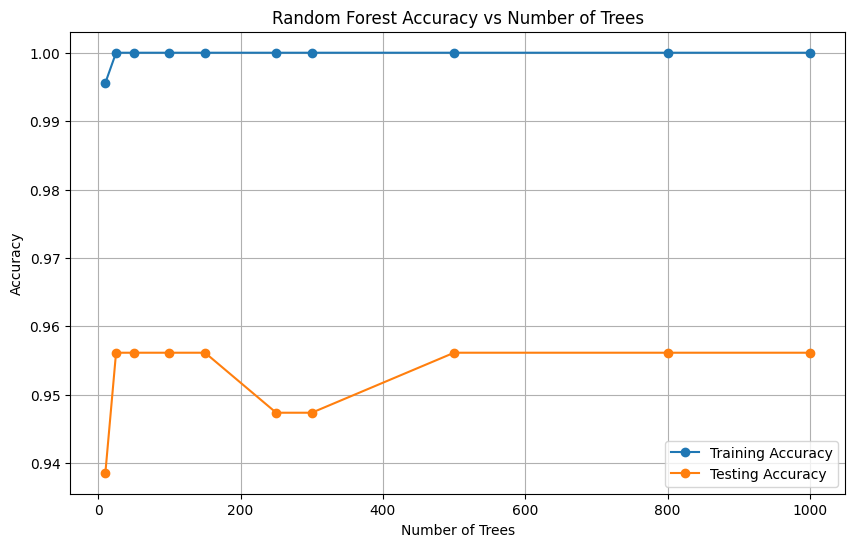

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(n_trees, rf_train_scores, marker="o", label="Training Accuracy")
plt.plot(n_trees, rf_test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.legend()
plt.grid()
plt.show()

### Number of Trees Analysis

Increasing the number of trees generally improves the stability of the Random Forest.

However, after a certain number of trees, the testing accuracy becomes relatively stable. Adding more trees therefore does not necessarily produce a significant improvement in performance.


##### Random Forest Feature Importance

We analyze the feature importance obtained from the Random Forest.

In [64]:
rf_feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
)

rf_feature_importance = rf_feature_importance.sort_values(
    ascending=False
)

rf_feature_importance.head(10)

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64

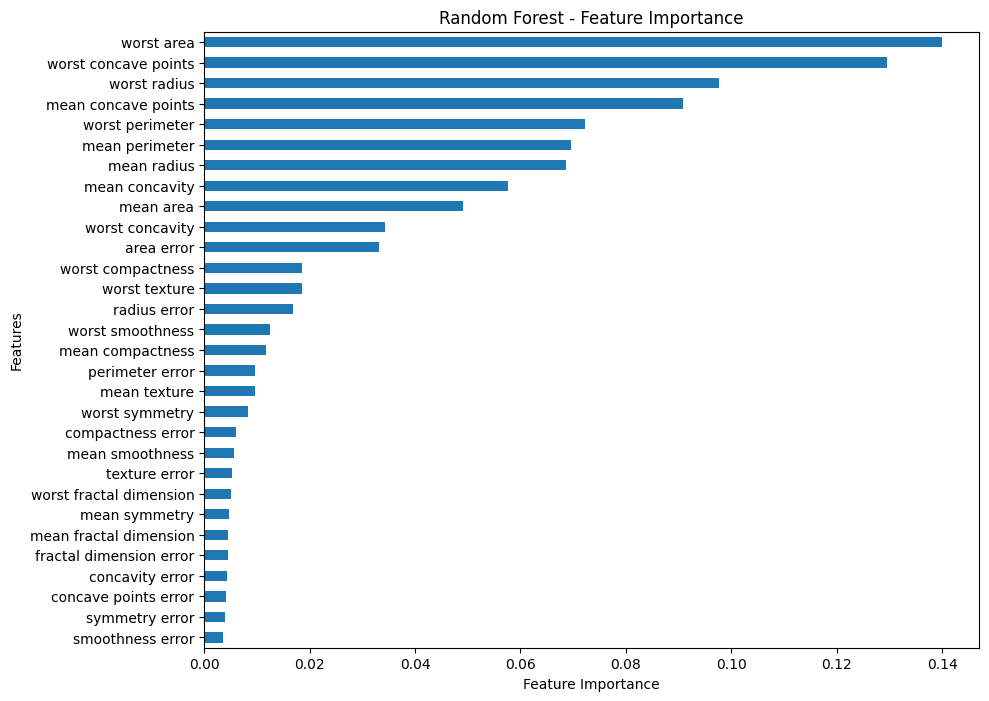

In [65]:
plt.figure(figsize=(10, 8))

rf_feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance")
plt.show()

### Random Forest Feature Importance

The most important features are **worst area**, **worst concave points**, **worst radius**, and **mean concave points**.

These features describe important characteristics of the cell nuclei, particularly their size and shape.

The Random Forest distributes importance across several features instead of relying mainly on one feature.


##### Compare feature importance

In [66]:
importance_comparison = pd.DataFrame({
    "Decision Tree": feature_importance,
    "Random Forest": rf_feature_importance
})

importance_comparison = importance_comparison.sort_values(
    "Random Forest",
    ascending=False
)

importance_comparison.head(10)

,Decision Tree,Random Forest
worst area,1.180873e-02,0.140016
worst concave points,5.345771e-02,0.129530
worst radius,0.000000e+00,0.097696
mean concave points,8.917668e-02,0.090885
worst perimeter,7.059305e-01,0.072226
mean perimeter,0.000000e+00,0.069574
mean radius,0.000000e+00,0.068676
mean concavity,1.959217e-17,0.057638
mean area,0.000000e+00,0.049172
worst concavity,1.338877e-02,0.034340


### Feature Importance Comparison

The two models identify several common important features, especially features related to **radius, perimeter, area, and concave points**.

However, the Decision Tree relies heavily on **worst perimeter**, while the Random Forest distributes importance more evenly across several features.

This difference is expected because the Random Forest combines many different decision trees.


##### Out-of-Bag Evaluation

We use the Out-of-Bag score as an additional evaluation metric.

In [67]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train, y_train)

print("OOB Score:", rf_oob.oob_score_)

OOB Score: 0.9604395604395605


### Out-of-Bag Score

The Random Forest obtained an **OOB score of 96.04%**.

This result is very close to the testing accuracy of **96%**, suggesting that the model has stable performance on unseen observations.


### PART 4: Feature Importance Analysis

We compare the feature importance rankings of the Decision Tree and Random Forest.

In [68]:
top_dt = feature_importance.head(10)
top_rf = rf_feature_importance.head(10)

print("Top 10 Decision Tree features:")
print(top_dt)

print("\nTop 10 Random Forest features:")
print(top_rf)

Top 10 Decision Tree features:
worst perimeter         0.705931
mean concave points     0.089177
worst texture           0.062538
worst concave points    0.053458
compactness error       0.027027
worst concavity         0.013389
worst area              0.011809
area error              0.011241
concavity error         0.011111
mean texture            0.007331
dtype: float64

Top 10 Random Forest features:
worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64


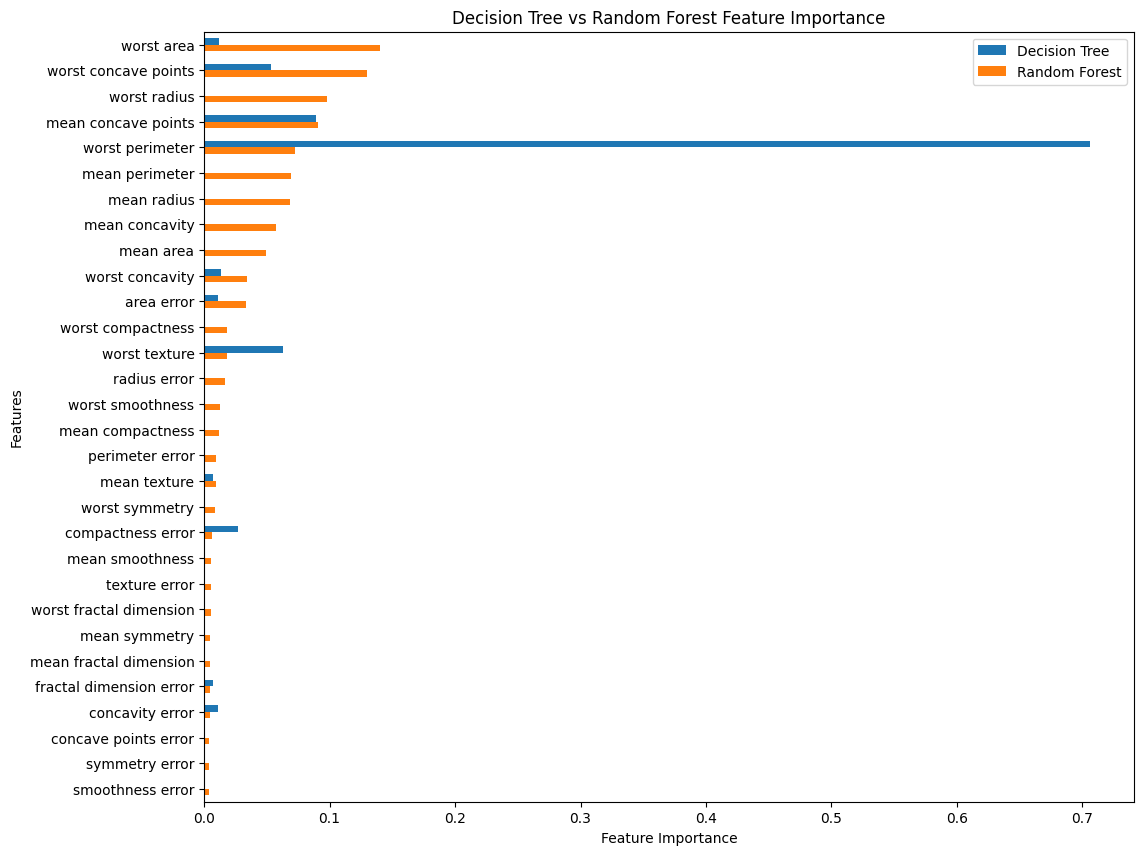

In [69]:
importance_comparison.plot(
    kind="barh",
    figsize=(12, 10)
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Decision Tree vs Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### QUESTIONS FOR ANALYSIS

#### 1- Decision Trees

1. The Decision Tree achieved 100% training accuracy and 92.98% testing accuracy.

The lower testing accuracy compared with the training accuracy indicates overfitting. The tree fits the training data perfectly but performs slightly worse on unseen data.

2. Restricting the maximum depth reduces the complexity of the Decision Tree.

This can reduce overfitting and make the model easier to interpret. However, if the depth is too small, the model may underfit and fail to capture important patterns in the data.

3. The Gini criterion performed better on the testing set.

Gini achieved an accuracy of 92.98%, compared with 91.23% for Entropy.

The difference is relatively small, but Gini gave the better result in our experiment.

4. The **worst perimeter** is the most important feature in the Decision Tree, with an importance of approximately **0.706**.

Other important features include **mean concave points**, **worst texture**, and **worst concave points**.

These features are likely used early in the tree because they provide useful information for separating malignant and benign tumors.

#### 2 - Random Forest

1. The Random Forest achieved 96% testing accuracy, compared with 92.98% for the Decision Tree.

It also achieved high precision, recall and F1-scores for both classes.

The results show that the Random Forest performs better on the testing set and provides more robust generalization than the single Decision Tree in this experiment.

2. Increasing the number of trees improves the stability of the Random Forest.

However, after a certain point, the testing accuracy becomes relatively stable. Therefore, adding more trees does not always lead to a significant improvement in accuracy, while it increases computational cost.

3. The most important features are worst area, worst concave points, worst radius, and mean concave points.

These features describe the size and shape of cell nuclei and are therefore relevant to distinguishing the two classes.

4. A Random Forest combines many decision trees, which helps reduce variance and makes the model more robust to overfitting.

Its main disadvantage is lower interpretability compared with a single Decision Tree.

#### 3 - General Comparison

1. & 2. The Decision Tree achieved 92.98% testing accuracy, while the Random Forest achieved 96%.

The Random Forest also obtained an OOB score of 96.04%, which is consistent with its testing performance.

Overall, the Random Forest showed better generalization in our experiment, while the Decision Tree remains easier to interpret and visualize.

3. The models could be improved through more extensive hyperparameter tuning and cross-validation.

Other ensemble methods such as Bagging, Boosting, or Gradient Boosting could also be tested and compared with the current models.

#### 4 - Conclusion

The Decision Tree achieved 92.98% testing accuracy, while the Random Forest achieved 96%.

The Decision Tree showed signs of overfitting, with 100% training accuracy compared with 92.98% testing accuracy. The Gini criterion performed slightly better than Entropy.

The Random Forest provided better testing performance and an OOB score of 96.04%. Its feature importance was also distributed across several relevant features, mainly related to cell size and shape.

Overall, the experiments highlight the importance of hyperparameter tuning, model evaluation, feature importance, and the bias-variance trade-off.

